# UrbanFlow

**The purpose of this NoteBook is to walk a user through the advanced usage of *geo3D* products.**

<div class="alert alert-block alert-warning"><b>This notebook will:</b>

> **1. allow the user to create a Level-of-Detail 1 (LoD1) [3D City Model](https://en.wikipedia.org/wiki/3D_city_model).**  *---It saves the `overpass`.geojson to prevent calling OSM after every failure. Peruse `matplotlib` figure at you leisure.* 
>
> **2. create a Boundary Representation (B-Rep) .step file .** to load into SimScale with a very brief step-by-step walk-through to illustrate how we execute an Incompresible Fluid Flow [**Computational Fluid Dynamics**](https://en.wikipedia.org/wiki/Computational_fluid_dynamics) Simulation
> > **a.** harvest the SimScale result to estimate **Pedestrian Wind Comfort (PWC)**
> > 
> > **b.** calculate a **Universal Thermal Comfort Indicator (UTCI)** in summer and winter, and
> > 
> > **c.** lastly estimate the **Wind Chill Index** 
>
> **2. propose several [Geography and Sustainable Development Education *conversation starters*](#Section2) for Secondary and Tertiary level students**
</div>

<div class="alert alert-block alert-danger"><b>Please Note:</b>

This processing option is meant for areas no greater than for **500m in diameter**.</div>

In [1]:
import time
import datetime
from datetime import timedelta
from zoneinfo import ZoneInfo
import math

import os
import sys
from itertools import chain

import requests
import overpass

import numpy as np
import pandas as pd
import topojson as tp

import shapely
import shapely.geometry as sg
from shapely.geometry import Point, LineString, Polygon, MultiPolygon, LinearRing, polygon, shape, mapping
from shapely.ops import snap, transform, unary_union
from shapely.strtree import STRtree

import fiona
import copy
import json
import geojson

import pyproj

from osgeo import gdal, ogr, osr

import triangle as tr

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

In [2]:
#- get current working directory (notebook location)
current_dir = os.getcwd()

#- go one level up
parent_dir = os.path.dirname(current_dir)
# Add parent directory to sys.path if needed
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

#- import
import city3D

In [3]:
import warnings
Tstart = time.time()
warnings.filterwarnings('ignore')

**A `parameter.json` defines the path and files**.

In [4]:
#- _param.json

#jparams = json.load(open('../param/wStock_param.json'))
#jparams = json.load(open('../param/saao_param15m.json'))
#jparams = json.load(open('../param/mamre_param.json'))
jparams = json.load(open('../param/durham_param.json'))

In [5]:
#center_lat, center_lon =  -33.92819, 18.44359 # wStockQuarter
center_lat, center_lon = -33.93379, 18.45964 # durham
#center_lat, center_lon = -33.51356, 18.47595 # mamre
#center_lat, center_lon = -33.934516, 18.477391 # saao

**First get everything via `overpass`**

In [6]:
query = """
    [out:json][timeout:180];
    (
        // I want all buildings ~ with levels tagged
        way(around:250,{0}, {1})['building'];
        // and relation type=multipolygon ~ to removed courtyards from buildings
        relation(around:250,{0}, {1})['building']["type"="multipolygon"];
    );
    out count;
    out geom;
    """.format(center_lat, center_lon)

In [7]:
#- execute function and harvest blds. 
gdf = city3D.overpass_to_gdf(query)
gdf.head(2)

,addr:city,addr:street,amenity,building,building:levels,denomination,name,religion,service_times,addr:housename,...,social_facility,surface,start_date,layer,type,operator:type,social_facility:for,geometry,osm_id,osm_type
0,Salt River,Coleridge Road,place_of_worship,church,2,roman_catholic,St. Francis Catholic Church,christian,Su 08:00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((18.4610767 -33.9326615, 18.46117 -33...",686465967,way
1,Cape Town,Durham Avenue,NaN,apartments,11,NaN,NaN,NaN,NaN,Durham Square Apartment Complex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((18.4596569 -33.9334083, 18.4599646 -...",739895556,way


In [8]:
#- some print statements
print(len(gdf))
#print(jparams['FocusArea'], 'has', len(gdf), 'buildings')
#if int(len(gdf)) < 2500:
#    print('\n\033[1mAll the buildings\033[0m  in' 'have been harvested')
#else:
#    print('\n', int(len(gdf))-2500, "buildings have not been harvested.")

145


<div class="alert alert-block alert-info"><b></b>
    

</div>

In [9]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<img src="../data/proj.png" alt="proj" width="550" align="right"/>
<br>
<br>

We need the ***Projected*** Coordinate Reference System.  

In [10]:
#- estimate utm: internal geopandas function
gdf.estimate_utm_crs()

<Projected CRS: EPSG:32734>
Name: WGS 84 / UTM zone 34S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 18°E and 24°E, southern hemisphere between 80°S and equator, onshore and offshore. Angola. Botswana. Democratic Republic of the Congo (Zaire). Namibia. South Africa. Zambia.
- bounds: (18.0, -80.0, 24.0, 0.0)
Coordinate Operation:
- name: UTM zone 34S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
**Fill in the proper `espg` in the _`cell`_ below** </div>

In [11]:
#- fill <Projected CRS: EPSG:32734> from above here epsg = EPSG:32734
epsg = 32734

In [12]:
#project blds
gdf = gdf.to_crs(epsg)

In [13]:
# 1. Your variables
radius = 400 # do NOT change this number. Please do NOT burden simscale with enormous datasets.

# 1. Correct point (lon, lat)
p = city3D.GeoDataFrameLite({
    'name': ['Center Point'],
    'geometry': [Point(center_lon, center_lat)]
})

p.crs = "EPSG:4326"

# 2. Project to metric CRS (e.g. UTM 34S)
local_point = p.to_crs(epsg)

# 3. Buffer in meters
circle_poly = local_point.geometry.iloc[0].buffer(radius)

# 4. Convert BACK to WGS84 (important!)
circle_poly_wgs84 = city3D.GeoDataFrameLite({
    'geometry': [circle_poly]
})
circle_poly_wgs84.crs = epsg
#circle_poly_wgs84 = circle_poly_wgs84.to_crs("EPSG:4326")

# 5. Final AOI
aoi = city3D.GeoDataFrameLite({
    'id': ["area_of_interest"], #Durham Residential Apartments, Salt River"],
    'lat': [center_lat],
    'lon': [center_lon],
    'geometry': [circle_poly_wgs84.geometry.iloc[0]]
})

#aoi.crs = "EPSG:4326"
aoi.head()

,id,lat,lon,geometry
0,area_of_interest,-33.93379,18.45964,"POLYGON ((265592.1892996717 6242278.232689339,..."


In [14]:
#local_point

**Now we process.**  

**If you change the *geometry, shape or alignment* of a building in an [OSM editor](https://wiki.openstreetmap.org/wiki/Editors); call / retrieve only what you need; and continue.**

In [15]:
#project aoi 

#aoi = aoi.to_crs(epsg)
#aoi.head(2)

In [16]:
#aoibuffer = aoi.copy()

#def buffer01(row):
#    with np.errstate(invalid='ignore'):
#        return row.geometry.buffer(150, cap_style=3, join_style=2)

#aoibuffer['geometry'] = aoibuffer.apply(buffer01, axis=1)

# Suppose 'aoi' is your GeoDataFrameLite or list of geometries
geoms = aoi['geometry'].tolist()

#- combine all geometries into a single union
combined_geom = shapely.unary_union(geoms)  # returns Polygon or MultiPolygon
#- compute centroid
xy = (combined_geom.centroid.x, combined_geom.centroid.y)
#- compute bounding box
minx, miny, maxx, maxy = combined_geom.bounds
extent = [minx - 250, miny - 250,
          maxx + 250, maxy + 250]

In [17]:
aoi

,id,lat,lon,geometry
0,area_of_interest,-33.93379,18.45964,"POLYGON ((265592.1892996717 6242278.232689339,..."


**Now the DEM**  
*three are available at [raster](https://github.com/AdrianKriger/geo3D/tree/main/raster)*

In [18]:
gdal.SetConfigOption("GTIFF_SRS_SOURCE", "GEOKEYS")

# set the path and nodata
OutTile = gdal.Warp(jparams['projClip_raster'], 
                    jparams['in_raster'],
                    dstSRS=f"EPSG:{epsg}",
                    srcNodata = jparams['nodata'],
                    #-  dstNodata = 0,
                    #-- outputBounds=[minX, minY, maxX, maxY]
                    outputBounds = [extent[0], extent[1], extent[2], extent[3]])
OutTile = None 

In [19]:
#- convert raster to XYZ in-memory

#- virtual in-memory path
xyz_mem_path = "/vsimem/temp_xyz.xyz"  
gdal.Translate(xyz_mem_path, jparams['projClip_raster'], format="XYZ")  

#- read XYZ from GDAL's in-memory file
xyz_vsimem = gdal.VSIFOpenL(xyz_mem_path, "rb")
xyz_bytes = gdal.VSIFReadL(1, gdal.VSIStatL(xyz_mem_path).size, xyz_vsimem)
gdal.VSIFCloseL(xyz_vsimem)
#- cleanup in-memory file
gdal.Unlink(xyz_mem_path) 

0

**prepare to harvest elevation**

In [20]:
# set the path to the projected, cliped elevation
src_filename = jparams['projClip_raster']

src_ds = gdal.Open(src_filename) 
gt_forward = src_ds.GetGeoTransform()
rb = src_ds.GetRasterBand(1)

**Buildings**

In [21]:
gdf.head(2)

,addr:city,addr:street,amenity,building,building:levels,denomination,name,religion,service_times,addr:housename,...,social_facility,surface,start_date,layer,type,operator:type,social_facility:for,geometry,osm_id,osm_type
0,Salt River,Coleridge Road,place_of_worship,church,2,roman_catholic,St. Francis Catholic Church,christian,Su 08:00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((265321.9194704897 6242406.692677797,...",686465967,way
1,Cape Town,Durham Avenue,NaN,apartments,11,NaN,NaN,NaN,NaN,Durham Square Apartment Complex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((265192.7032025485 6242320.608864319,...",739895556,way


In [22]:
#- harvest buildings

ts = gdf.copy()
ts = ts.loc[:,~ts.columns.duplicated()]

#- home-baked gdf
ts = city3D.GeoDataFrameLite(ts)
geojson_str = ts.to_json()
geojson_dict = json.loads(geojson_str)

#- orient segments and simplify topology
topo = tp.Topology(geojson_dict, prequantize=False, winding_order='CCW_CW')
with np.errstate(invalid='ignore'):
    #simplified = topo.toposimplify(0.25).to_gdf()
    simplified_geojson = topo.toposimplify(0.25).to_geojson()

#- convert back to home-baked gdf
ts = city3D.GeoDataFrameLite.from_json(simplified_geojson)
ts.crs = epsg

In [23]:
#ts.head(3)
#len(ts)

In [24]:
# prepare to plot (more buildings = more time) 
start = time.time()

ts_copy = ts.copy()

geoms = ts_copy["geometry"].tolist()
tree = STRtree(geoms)

#- Query the tree for overlaps
# This returns two arrays: 'i' (index in geoms we are checking) and 'j' (index in the tree it overlapped with)
# Vectorized query: fastest way to find overlaps
i, j = tree.query(geoms, predicate="overlaps")

#- filter self-matches and get unique indices of all involved buildings
mask = i != j
overlap_idx = set(i[mask])

new_df1 = ts_copy.iloc[list(overlap_idx)].reset_index(drop=True)

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

runtime: 0:00:00.008644


**Plot**

*Browse the saved `'./data/topologyFig'` at your leisure*

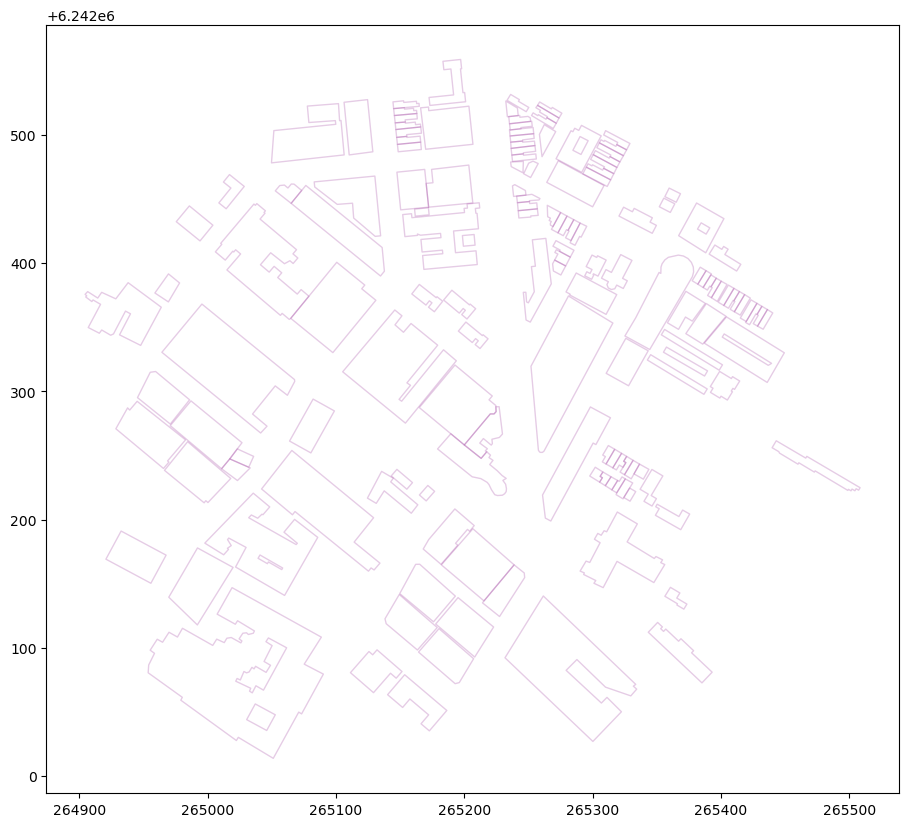

In [25]:
#%matplotlib

#- usage:
fig, ax = plt.subplots(figsize=(11, 11))
city3D.plot_geometries(ts_copy, ax=ax, facecolor='none', edgecolor='purple', alpha=0.2)
if len(new_df1) > 0:
    city3D.plot_geometries(new_df1, ax=ax, facecolor='none', edgecolor='red', alpha=0.5)
#-- save
plt.savefig('../data/topologyFig.png', dpi=300)
#plt.show()

|  |  |
|:--------:|:--------:|
|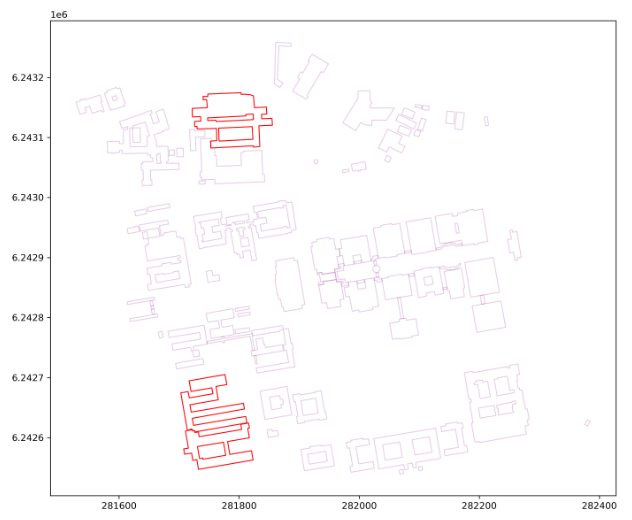 | **Challenges will be highlight in *Red*.**|
|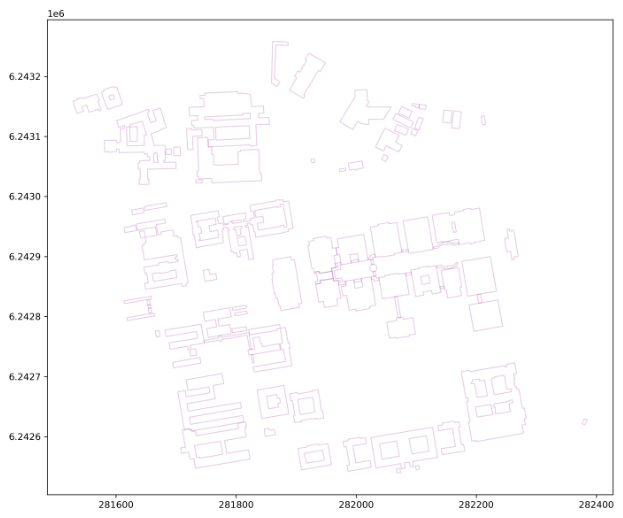 | **or none**|
|<br /> **If you continue without fixing the challenges, the LoD1 City Model *will not be error free*.** | <br /> **Our goal is a topologically correct surface.** |

<h2><center>Please ensure the quality of the value-added product and the source data.</center></h2>

**If necessary; edit [OpenStreetMap](https://www.openstreetmap.org/about) and fix the challenge please.**

<div class="alert alert-block alert-success"><b></b>
    
*And remember; give the OpenStreetMap server at **least a day** before attempting to work through this Notebook again.*  
*Alchemy is a process. **Please be patient**.*
</div>

<div class="alert alert-block alert-warning"><b>Calculate building height:</b> 

We assume a building level is 2.8 meters high and add another 1.3 meters (to account for the roof) and create a new `building_height` attribute .</div>

The Python code to execute the `.bldHeights` function is in the `city3D.py` script

In [26]:
# -- execute function.
dis = city3D.bldHeights(ts)

In [27]:
#- we only need structures that touch the ground

start = time.time()

dis_c = dis.copy()
dis_c.drop(dis.index[dis['building'] == 'bridge'], inplace = True)                           #- skywalk
dis_c.drop(dis.index[dis['building'] == 'roof'], inplace = True)

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

runtime: 0:00:00.001506


**prepare the elevation for the TIN**

In [28]:
#- prepare xyz (more buildings = more time)
start = time.time()

# Convert bytes to DataFrame
xyz_str = xyz_bytes.decode("utf-8")  # Decode to string

dtype_spec = {
    "x": np.float32,  # Reduce precision from float64 to float32 (saves memory)
    "y": np.float32,
    "z": np.float32
}

#df = pd.read_csv(jparams['xyz'], delimiter = ' ', header=None, names=["x", "y", "z"])                                                                                
df = pd.read_csv(pd.io.common.StringIO(xyz_str), delimiter=" ",  header=None, 
                 names=["x", "y", "z"], dtype=dtype_spec)                     # in memory fastest

#- create the shapely 'geometry' column directly (Vectorized) and 'plop' into home-baked gdf
df['geometry'] = df.apply(lambda row: Point(row['x'], row['y']), axis=1) 
gdf = city3D.GeoDataFrameLite(df) 
gdf.crs = epsg

# --- final cleanup ---
gdf = gdf[gdf['z'] != jparams['nodata']] 
gdf.reset_index(drop=True, inplace=True)
print(len(gdf))

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

2704
runtime: 0:00:00.034440


In [29]:
#aoi.geometry

<div class="alert alert-block alert-warning"><b>Prepare for Triangle:</b> </div>

The Python code to execute the `city3D.functions` are in the `city3D.py` script

In [30]:
#- harvest the building vertices, combine with the elevation, create regions and segments for Triangle
coords, regions, segments = city3D.prepareTri(gdf, dis_c, aoi)

**Triangle**

In [31]:
A = dict(vertices=np.array(coords), segments=np.array(segments), #holes=np.array(holes), 
         regions=np.array(regions))

# 'p'  = Triangulate the PSLG: Delauney triangulation with segments (building outlines) as constraints.
# 'Y' = Do NOT add Steiner points
# 'A'  = Attribute triangles with region IDs
# 'z'  = Zero-based indexing (prevents index errors)
Tr = tr.triangulate(A, 'pYAz')

In [32]:
#- the vertices 
final_verts_2d = Tr['vertices']

#- round to 3 decimals to match your get_pt_idx rounding
z_cache = {(row.x, row.y): row.z for row in gdf.itertuples()}

## -- we triangulate in 2D and project into 3D space. the vertices of the building outlines need a 'z'-value
final_verts_3d = []
for x, y in final_verts_2d:
    x_r, y_r = x, y
    
    # 2. Check if we already have the Z value in our GDF points
    if (x_r, y_r) in z_cache:
        z = z_cache[(x_r, y_r)]
    else:
        # 3. Only query the raster if the point is a new vector/Steiner vertex
        z = float(city3D.rasterQuery2(x, y, gt_forward, rb))

    final_verts_3d.append([x, y, z])

final_verts_3d = np.array(final_verts_3d)

#- separate triangles by their Region ID for CityJSON
tris = Tr['triangles']
tri_attr = Tr['triangle_attributes'].flatten()

**CityJSON**

In [33]:
#- 
minz = gdf['z'].min()
maxz = gdf['z'].max()

## 1. Level-of-Detail 1 (LoD1) 3D City Model

<div class="alert alert-block alert-warning"><b>create CityJSON</b> </div>

The Python code to execute the `.output_cityjson` function is in the `city3D.py` script

In [34]:
# -- execute function. create CityJSON 
city3D.output_cityjson(extent, minz, maxz, tris, tri_attr, final_verts_3d, dis, jparams, gt_forward, rb, epsg)

In [35]:
src_ds = None

<div class="alert alert-block alert-info"><b></b> 

**Go over to [Ninja the online CityJSON viewer](https://ninja.cityjson.org/#) and explore!**

</div>

**You are welcome to further investigate the quality of a 3D Model.**

**The [val3dity](http://geovalidation.bk.tudelft.nl/val3dity/) web app will test CityJSON geometric primitives.**

**If you parse the result of this notebook through [val3dity](http://geovalidation.bk.tudelft.nl/val3dity/) it will return a report with an invalid [TINRelief](https://www.cityjson.org/specs/1.1.1/#tinrelief) and error.**

|  |  | 
| :---: | :---: |
| **This particular area contains Buildings with courtyards. The courtyards** (polygons) **are islands of terrain disconnected from the *larger* TINRelief** (shell); **thus the error<sup>*</sup>.**|![iso19107_error.jpg](../data/iso19107_error.jpg) |

<sup>*<sub> ***Don't take my word for it. Test and see for yourself!*** `saao_param.json` (South African Royal Observatory, Cape Town) will produce a 100% topologically correct [Open Geospatial Consortium (OGC)](https://www.ogc.org/standard/citygml/) standard LoD1 3D model that conforms to the [ISO 19107 spatial schema for 3D primatives](https://www.iso.org/standard/66175.html) *[connecting and planar surfaces, correct orientation of the surfaces and watertight volumes]*</sub> 

<div class="alert alert-block alert-warning"><b>NOW</b><br><br>


***To understand the value and usefulness of a 3D City Model***; parse the result of this Notebook through [CityJSONspatialDataScience.ipynb](https://github.com/AdrianKriger/geo3D/blob/main/CityJSONspatialDataScience.ipynb) to workthrough an example of:  
- population estimation and
- a calculation of [**Building Volume per Capita**](https://www.researchgate.net/publication/343185735_Building_Volume_Per_Capita_BVPC_A_Spatially_Explicit_Measure_of_Inequality_Relevant_to_the_SDGs), and
- estimate the [**Annual Average Solar** *(photovoltaic)* **Potential**](https://www.worldbank.org/en/topic/energy/publication/solar-photovoltaic-power-potential-by-country), per home.
</div>

***As always; you are welcome to raise an issue. I depend on you to help me improve.***

<a id='Section2'></a>

In [36]:
Tend = time.time()
print('runtime:', str(timedelta(seconds=(Tend - Tstart)))) #previous [2023] uEstate: 0:00:11.05 | mamre: 0:03:46.7

runtime: 0:00:04.233724


## 2. Boundary Representation (B-Rep) 

<div class="alert alert-block alert-warning"><b>create .STEP</b> for SimScale</div>


In [37]:
#- .step for simScale
start = time.time()

city3D.exportStep(dis_c, extent, "../result/durhamUnion02.step")

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

runtime: 0:00:00.000013


## 3. Simulation

<div class="alert alert-block alert-danger"><b></b>
    
As you would have noticed we are executing an analysis over a tiny area: a **500m diameter circle**. While SimScale does allow members of its [**Community plan**](https://www.simscale.com/product/pricing/) to interogate a larger area; **please don't**.  
Please do NOT take advantage of the extremely generous [**Community plan**](https://www.simscale.com/product/pricing/) by burdening the SimScale server. 

The inclusion of these technically rigorous [CFD analysis]() within the ***geo3D* framework is provide a *taste* of what is possible**. You are welcome to explore [SimScale's subscriptions plans](https://www.simscale.com/product/pricing/) for its full range of extremely comprehensive simulation offerings.</div>

<div class="alert alert-block alert-info"><b>These analysis expect the user to have some basic knowledge about the environment under inquiry / investigation</b> </div>

We will now very briefly walk-through a [**Incompressible Fluid Flow Analysis**](https://www.simscale.com/docs/analysis-types/incompressible-fluid-flow-analysis/) on [SimScale]() *--so that you can do your own neighbourhood*.  
Please have a look at [the reference **Incompressible Fluid Flow** SimScale project](https://www.simscale.com/workbench/?pid=3569060121810782207&mi=spec:f69cbd01-dc04-47d8-9a9a-f9e55acc05ef%2Cservice:SIMULATION%2Cstrategy:1).

Once a SimScale account and Project has been created: 

|  |  |  |  |  |  | 
| :--- | :---: | :---| :---:| :--- | :---: |
| | Import the model| | | | Duplicate the geometry | 
| 1.| ![1.jpg](../data/simPics/1.jpg)|2. |![2.jpg](../data/simPics/2.jpg) | 3.|![3.jpg](../data/simPics/3.jpg) |
| | External Flow Volume (EFV) | | Define dimensions of the EFV | | Turn off EFV and select the model | 
| 4.| ![4.jpg](../data/simPics/4.jpg)|5. | ![5.jpg](../data/simPics/5.jpg)|6. |![6.jpg](../data/simPics/6.jpg) |
| | | | Delete the model| | Look at the bottom of the EFV | 
| 7.| ![7.jpg](../data/simPics/7.jpg)|8. | ![8.jpg](../data/simPics/8.jpg)|9. |![9.jpg](../data/simPics/9.jpg) |
|  | Create Simulation | |Define Material Air | | Ensure EFV is Assigned | 
| 10.| ![10.jpg](../data/simPics/10.jpg)|11. | ![11.jpg](../data/simPics/11.jpg)|12. |![12.jpg](../data/simPics/12.jpg) |
|  | Boundary Condition. Velocity Inlet | |Boundary Condition. Pressure Outlet || Boundary Condition. Wall Slip (top and sides) | 
| 13.| ![13.jpg](../data/simPics/13.jpg)|14. | ![14.jpg](../data/simPics/14.jpg)|15. |![15.jpg](../data/simPics/15.jpg) |
|  | Boundary Condition. Wall No-slip (buildings NOT ground) | |Boundary Condition. Custom: Wall roughness No-slip (ground NOT buildings) | | Result Control. Forces and movements (buildings only)| 
| 16.| ![16.jpg](../data/simPics/16.jpg)|17. | ![17.jpg](../data/simPics/17.jpg)|18. |![18.jpg](../data/simPics/18.jpg) |
|  | Result Control. Surface data: Average area (buildings only) | |Field Calculations | | Mesh | 
| 19.| ![19.jpg](../data/simPics/19.jpg)|20. | ![20.jpg](../data/simPics/20.jpg)|21. |![21.jpg](../data/simPics/21.jpg) |
|  | Mesh Refinements. Surface custom sizing (buildings only) | |Generate Mesh and Run Simulation| | Download post processing results | 
| 22.| ![22.jpg](../data/simPics/22.jpg)|23. | |24. |![24.jpg](../data/simPics/24.jpg) |


The table below illustrates the typicaly $k$-value [SimScale's Community plan](https://www.simscale.com/product/pricing/) expects to classify *roughness* in its [Incompressible Fluid Flow Analysis](https://www.simscale.com/docs/analysis-types/incompressible-fluid-flow-analysis/). The $z$-value is the parameter the, Private plan, [Incompressible (LBM)](https://www.simscale.com/docs/analysis-types/incompressible-lbm/) solution accepts.

| Environment Type | Aerodynamic Roughness (z) | SimScale Input (k) | Real-World |
| :--- | :---: | :---: | ---:|
| Sea / Ice	| 0.0001 - 0.001 | 0.001 - 0.01 | Open water, calm to choppy |
| Featureless Land | 0.001 - 0.01 | 0.01 - 0.1 | Desert, airport runways, snow |
| Open Flat Land | 0.01 - 0.05 | 0.1 - 0.5 | Mown grass, prairie, off-runway|
| Agricultural | 0.1 - 0.3 | 1 - 3 | Low crops, small scattered bushes |
| Orchards / Woods | 0.4 - 0.7 | 4 - 7 |  Industrial / Fruit trees |
| Suburban / Forest | 0.7 - 1.5 | 7 - 15 |  Mixed-Use / Mature woods |
| Urban Centre | 1.5 - 3 | 15 - 30 |  City centers, tall buildings |
| Dense Skyscraper | 3 - 5+ | 30 - 50+ |  Extremely dense high-rise cores |

<div class="alert alert-block alert-danger"><b></b>

The [reference SimScale project](https://www.simscale.com/workbench/?pid=3569060121810782207&mi=run:43%2Csimulation:1&mt=SIMULATION_RUN) executes an Incompressible Fluid Flow simulation with a **standard mesh** which is ideal for ***geo3D*** -- *rapid iteration and engineering estimates* (the **`stand.:`** 11.1 and 9.8 m/s simulations)

The **quality of the standard mesh can fail** to meet the tolerances necessary to execute a simulation, especially if the complexity of the built environment is challenging to model.  

An example here would be when two buildings touch at a corner only. The walls don't touch; only a corner.  
In such cases the standard SimScale mesher will struggle, produce huge errors (non-orthagonality, edge ratios, etc.) and possibly fail. It then becomes necessary to execute a more rigorous meshing strategy.  
Bump up the mesh to a `Hex-dominant parametric`: the [reference SimScale project](https://www.simscale.com/workbench/?pid=3569060121810782207&mi=spec:f69cbd01-dc04-47d8-9a9a-f9e55acc05ef%2Cservice:SIMULATION%2Cstrategy:1) executes an Incompressible Fluid Flow simulation with a `hex-dominant parametric` mesh too (the **`hex-dom.:`** 11.1 and 9.8 m/s simulations)

**WARNING:**  
The `hex-dominant parametric` meshing strategy will execute a high intensity fluid flow simulation far beyond the needs to ***geo3D***. The result will be a high fidelity 1GB file compared to the less rigorous standard mesh solution (250MB).</div>

<div class="alert alert-block alert-warning"><b>Post processing results</b><br><br>

extract the `/polyMesh/points, owner, faces, neighbour and /1000/U` datafiles of the  [**Incompressible Fluid Flow Analysis**](https://www.simscale.com/docs/analysis-types/incompressible-fluid-flow-analysis/) result to the respective location: `../result/simScale/season` </div>

### a. Pedestrian Wind Comfort (PWC)

In this section we extract wind speeds, from the SimScale result, at typical pedestrian height (1.2 – 1.9 m) and categorize comfort levels. We evaluate **Pedestrian Wind Comfort (PWC)** to identify ***how vertical architectural forms interact with local wind regimes***.

Modern investigations into Wind Canyons and Downwash Effects have led to localized safety indicators. The most notable of these is the **Lawson Comfort Criteria (Lawson, T.V. 1978)**. Lawson defines comfort levels (m/s) based on the probability of wind speeds exceeding specific thresholds for activities like "Sitting," "Standing," or "Walking."

**PWC provides a direct spatial measure of urban livability**. By identifying "Acceleration Zones," we can evaluate how neighborhoods perform under the local winds. This analysis builds on the work of [**(Blocken, B; et al. 2012)**](https://www.sciencedirect.com/science/article/abs/pii/S1364815211002647) and directly supports [**SDG 11: Sustainable Cities and Communities**](https://sdgs.un.org/goals/goal11) by ensuring public spaces remain safe and usable year-round.

In this section, we analyze the results fro our [SimScale CFD-driven](https://www.simscale.com) ([Incompresible Fluid Flow Analysis](https://www.simscale.com/docs/analysis-types/incompressible-fluid-flow-analysis/)) simulation framework to explore [**Tier 3 local indicators**](https://unstats.un.org/sdgs/metadata/) of wind safety at a neighbourhood level. We evaluate the performance of our site under the two most frequent wind directions:

- The **Summer South-Easter** at a punchy 40 km/h (11.1m/s)

- A zesty 35 km/h (9.8m/s) **Winter North-Wester**

In [38]:
#- will take time if the points, neighbour, owner, faces and the 1000/U files from the SimScale post-processing.zip download is large
start = time.time()

#- harvest the data
summer_path = '../result/simScale/summer'

summerPed_dfFull, center_x_utm, center_y_utm = city3D.reconstruct_simscale_results(summer_path, center_lat, center_lon, radius=radius)
summerPed_df = summerPed_dfFull[(summerPed_dfFull['Z'] >= 1.2) & (summerPed_dfFull['Z'] <= 1.9)].copy()

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

summerPed_df.head(2)

runtime: 0:00:00.767837


,X,Y,Z,U,V,u_mag
18,265522.907934,6.242066e+06,1.556916,-1.757228,2.958470,3.441011
36,265474.218313,6.241999e+06,1.440406,-1.776095,2.784849,3.303055


| Ratio | Local Speed (umag) | Lawson Category (Typical) |
| :---: | :---: | :--- |
| < 0.5 | < 5.5 m/s | Sitting / Long-term |
| 0.5 - 0.75 | 5.5 - 8.3 m/s | Standing / Short-term |
| 0.75 - 1.0 | 8.3 - 11.1 m/s | Strolling / Walking |
| 1.0 - 1.2 | 11.1 - 13.3 m/s | Business Walking |
| > 1.2 | > 13.3 m/s | Uncomfortable / Distress |

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
Fill in the proper **SUMMER** Wind speed in m/s: `Su_inlet` </div>

In [39]:
Su_inlet = 11.1

In [40]:
def classify_lawson(r_ratio):
    if r_ratio < 0.5:
        return "Sitting/Long-term (Outdoor Dining)"
    elif r_ratio < 0.75:
        return "Standing/Short-term (Bus Stop)"
    elif r_ratio < 1.0:
        return "Strolling (Sightseeing)"
    elif r_ratio < 1.2:
        return "Business Walking (Commuting)"
    else:
        return "Uncomfortable/Distress"


# --- 4. LAWSON COMFORT ANALYSIS ---
# Your R calculation: u_pedestrian / u_inlet
# Since your SimScale run shows 11.1 m/s (40 km/h) as the inlet condition:
summerPed_df['R'] = summerPed_df['u_mag'] / Su_inlet
summerPed_df['lawson_class'] = summerPed_df['R'].apply(classify_lawson)

In [41]:
#-
len(summerPed_df)

3657

In [42]:
summerPed_df.head(3)

,X,Y,Z,U,V,u_mag,R,lawson_class
18,265522.907934,6.242066e+06,1.556916,-1.757228,2.958470,3.441011,0.310001,Sitting/Long-term (Outdoor Dining)
36,265474.218313,6.241999e+06,1.440406,-1.776095,2.784849,3.303055,0.297572,Sitting/Long-term (Outdoor Dining)
37,265498.752245,6.242022e+06,1.520004,-1.962131,2.993890,3.579616,0.322488,Sitting/Long-term (Outdoor Dining)


NameError: name 'summerPed_df' is not defined

In [2]:
summerPed_df.lawson_class.unique()

NameError: name 'summerPed_df' is not defined

In [44]:
# Get a percentage breakdown for your results section
print(summerPed_df['lawson_class'].value_counts(normalize=True) * 100)

lawson_class
Sitting/Long-term (Outdoor Dining)    99.644517
Standing/Short-term (Bus Stop)         0.300793
Strolling (Sightseeing)                0.054690
Name: proportion, dtype: float64


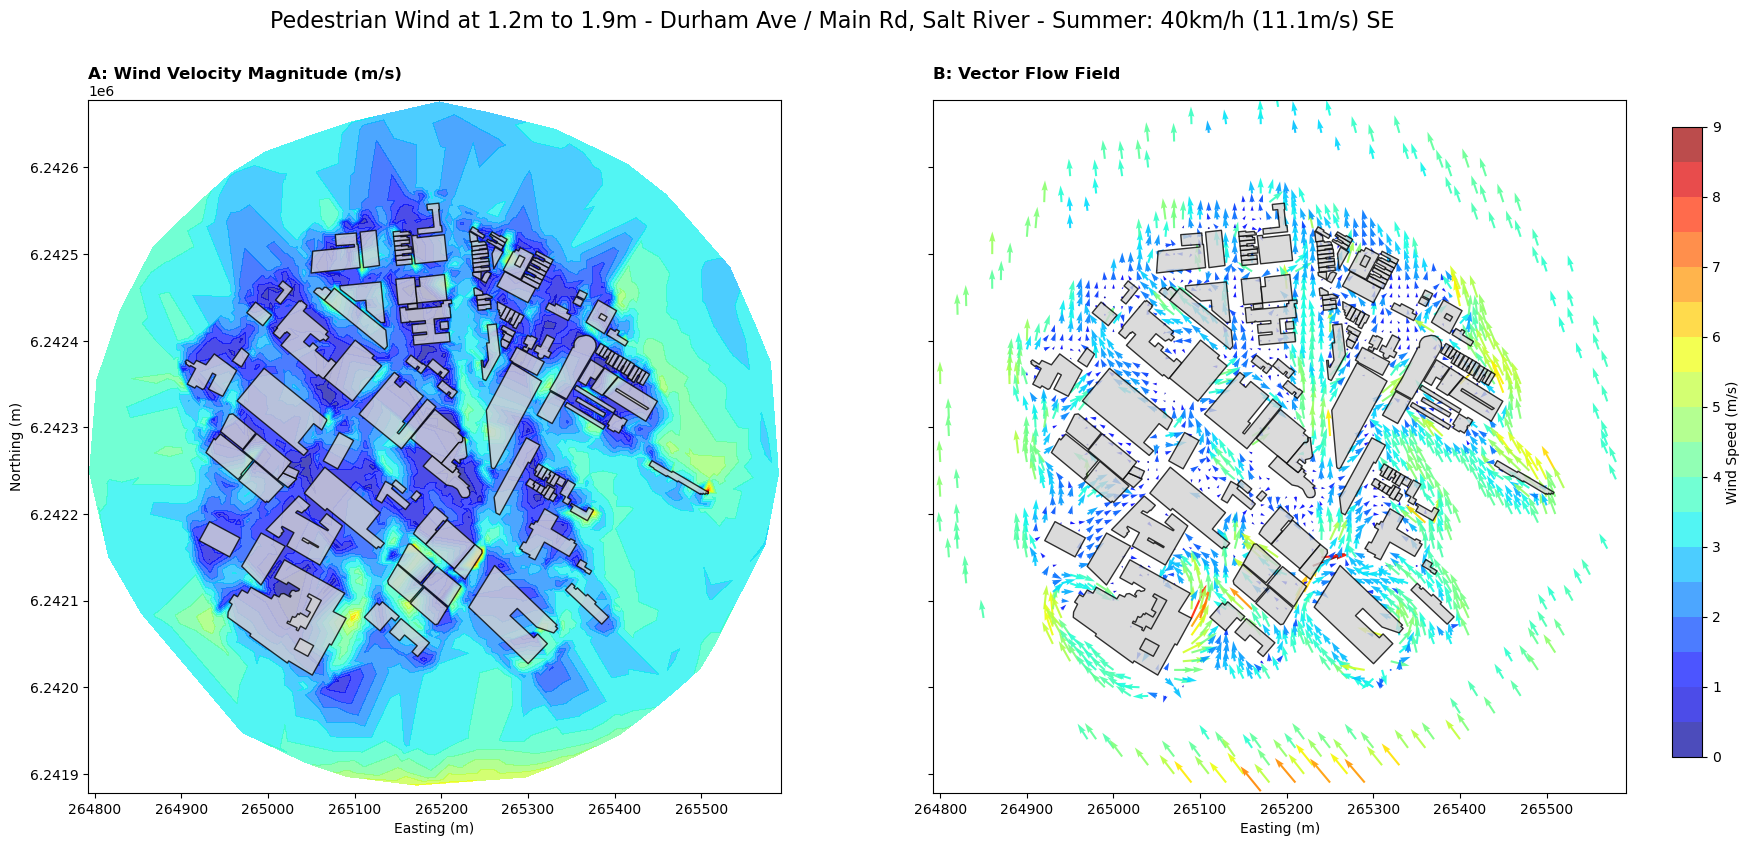

In [45]:
#- plot
fig, axes = city3D.plot_wind_analysis(summerPed_df, ts_copy, center_x_utm, center_y_utm, radius=radius, 
                          title_suffix="Durham Ave / Main Rd, Salt River - Summer: 40km/h (11.1m/s) SE")
plt.show()

The **Winter North-Wester**

In [46]:
#- will take time if the points, neighbour, owner, faces and the 1000/U files from the SimScale post-processing.zip download is large
start = time.time()

#- harvest the data
winter_path = '../result/simScale/winter'

winterPed_dfFull, center_x_utm, center_y_utm = city3D.reconstruct_simscale_results(winter_path, center_lat, center_lon, radius=400.0)
winterPed_df = winterPed_dfFull[(winterPed_dfFull['Z'] >= 1.2) & (winterPed_dfFull['Z'] <= 1.9)].copy()

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

winterPed_df.head(2)

runtime: 0:00:00.722978


,X,Y,Z,U,V,u_mag
18,265522.907934,6.242066e+06,1.556916,0.317848,-3.168905,3.184837
36,265474.218313,6.241999e+06,1.440406,0.311970,-3.349479,3.363985


<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
Fill in the proper **WINTER** Wind speed in m/s: `Wu_inlet` </div>

In [86]:
Wu_inlet = 9.8

In [87]:
# --- 4. LAWSON COMFORT ANALYSIS ---
# Your R calculation: u_pedestrian / u_inlet
# Since your SimScale run shows 9.8 m/s (35 km/h) as the inlet condition:
winterPed_df['R'] = winterPed_df['u_mag'] / Wu_inlet
winterPed_df['lawson_class'] = winterPed_df['R'].apply(classify_lawson)

In [88]:
len(winterPed_df)

903083

In [89]:
winterPed_df.lawson_class.unique()

array(['Sitting/Long-term (Outdoor Dining)',
       'Standing/Short-term (Bus Stop)', 'Strolling (Sightseeing)'],
      dtype=object)

In [90]:
# Get a percentage breakdown for your results section
print(winterPed_df['lawson_class'].value_counts(normalize=True) * 100)

lawson_class
Sitting/Long-term (Outdoor Dining)    95.760301
Standing/Short-term (Bus Stop)         4.142587
Strolling (Sightseeing)                0.097112
Name: proportion, dtype: float64


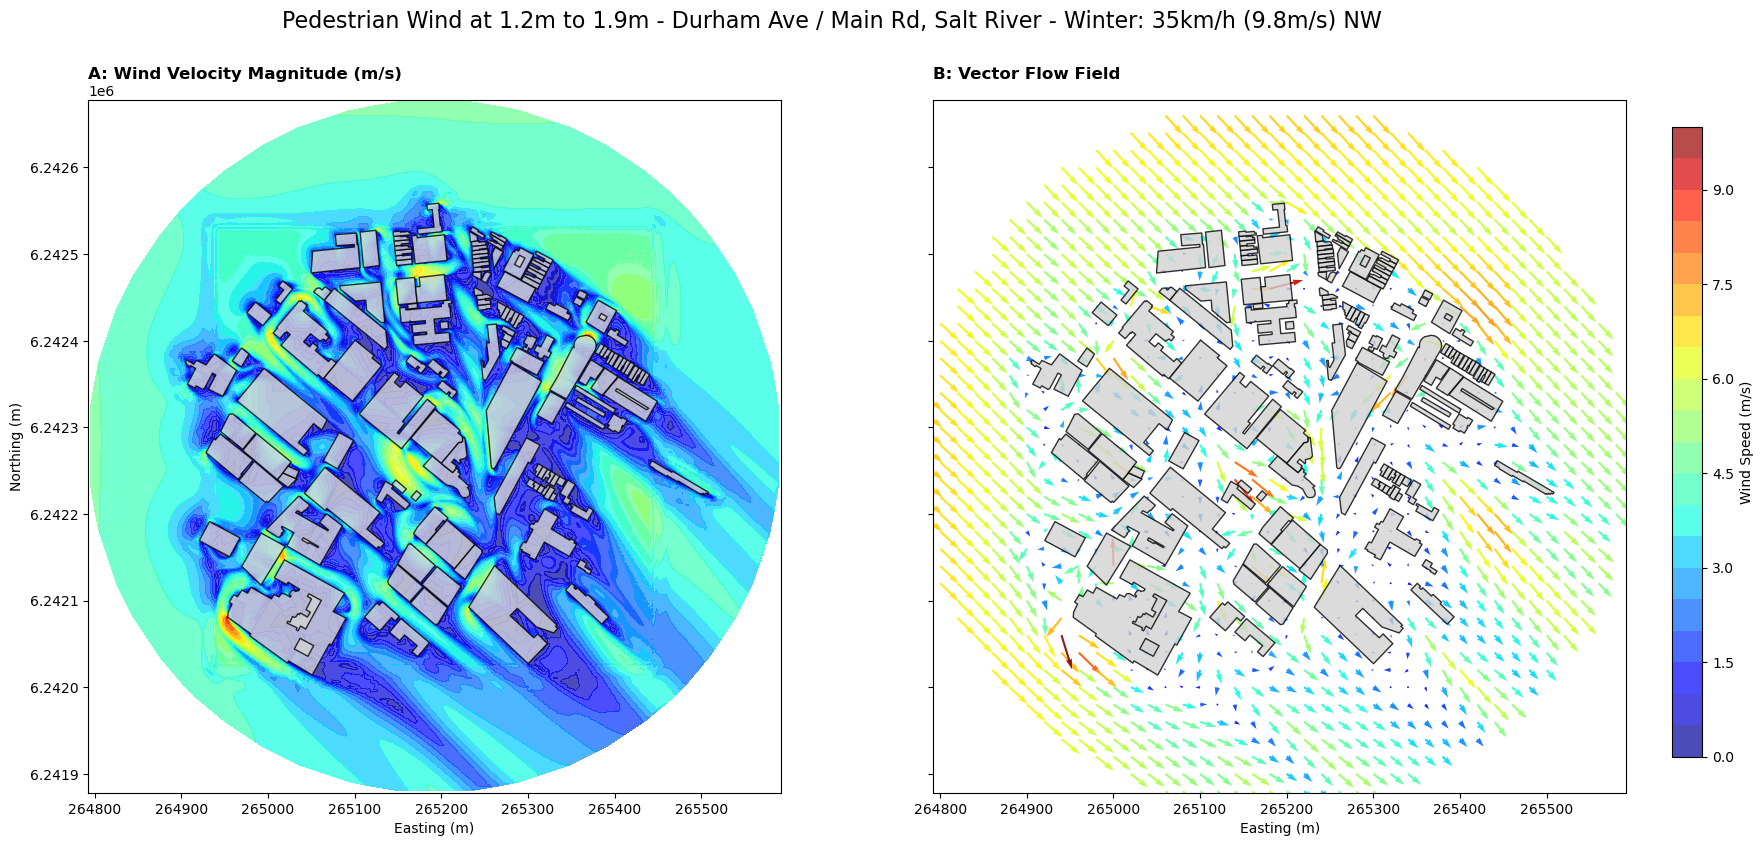

In [91]:
fig, axes = city3D.plot_wind_analysis(winterPed_df, ts_copy, center_x_utm, center_y_utm, radius=radius, 
                          title_suffix="Durham Ave / Main Rd, Salt River - Winter: 35km/h (9.8m/s) NW")
plt.show()

### b. Universal Thermal Comfort Indicator (UTCI)

In this section we combine [CFD-derived](https://en.wikipedia.org/wiki/Computational_fluid_dynamics) wind fields, from the previous section, with local solar radiation and temperature data and provide a **Decoupled Thermal Analysis** to estimate summer and winter comfort. 

While traditional planning treats temperature as a uniform regional value, modern investigations into **Urban Heat Islands (UHI)** require more granular indicators. The most robust of these is the **Universal Thermal Comfort Index (UTCI)** ([**Bröde, P; et al. 2012**](https://link.springer.com/article/10.1007/s00484-011-0454-1)). UTCI is a "felt temperature" ($^\circ\text{C}$) that integrates air temperature, humidity, wind speed, and radiant heat into a single value representing human physiological stress.

UTCI provides a spatial measure of climate vulnerability, identifying "Heat Traps" and "Wind Canyons." This analysis builds on the work of [**(Fiala, D; et al. 2012)**](https://link.springer.com/article/10.1007/s00484-011-0424-7) and aligns with [**SDG 11: Sustainable Cities and Communities**](https://unstats.un.org/sdgs/metadata/).

We now utilize the decoupled simulation framework (wind velocity harvested from SimScale CFD) and merge this with Solar Geometry: A custom Python ray-caster to determine the ***Shade vs. Sun*** status using [**NASA POWER climatology**](https://power.larc.nasa.gov).

By merging these, we explore [**Tier 3 local indicators**](https://unstats.un.org/sdgs/metadata/) of comfort at a neighborhood level, evaluating the site under seasonal extremes: 

- a **warm January Summer South-Easter** and
- the **cold July Winter North-Wester**.

<div class="alert alert-block alert-danger"><b>Technical Note on Thermal Accuracy:</b><br><br>

This **Universal Thermal Comfort Indicator** (UTCI) uses a **Decoupled Thermal Analysis**. We simulate the aerodynamic wind flow via [SimScale's](https://www.simscale.com) community-standard RANS (Reynolds-Averaged Navier-Stokes) solver ***and combine it with*** localized solar radiation and humidity data.

While this provides an excellent approximation of pedestrian comfort, a Robust [**Heat-Transfer Simulation**](https://www.simscale.com/docs/analysis-types/heat-transfer/) would be required for a formal [Environmental Impact Assessment](https://en.wikipedia.org/wiki/Environmental_impact_assessment). Such an analysis accounts for **Surface Albedo** *(e.g., how much heat a dark road absorbs vs. a light pavement)* and **Thermal Mass** *(how buildings, the earth, etc. store heat)*</div>

<div class="alert alert-block alert-info"><b>These analysis expect the user to have some basic knowledge about the environment under inquiry / investigation</b> </div>

<div class="alert alert-block alert-warning"><b>UTCI</b><br>

The following UTCI formula is a simplified polynomial regression of the original [UTCI Fiala model](https://www.utci.org). The 'Gold Standard' reference for the full version is:

[Bröde, P., et al. (2012). **Deriving the Operational Procedure for the Universal Thermal Comfort Index (UTCI).** *International Journal of Biometeorology, 56(3), 481–494*. DOI: 10.1007/s00484-011-0454-1](https://link.springer.com/article/10.1007/s00484-011-0424-7)</div>

In [92]:
def calculate_utci_robust(ta, mrt, v, rh):
    """
    Standard UTCI calculation based on the multi-node human heat balance model.
    ta: Air Temperature (°C)
    tr: Mean Radiant Temperature (°C)
    v: Wind speed at 10m height (m/s)
    rh: Relative Humidity (%)
    """
    # Offset from air temperature
    dtp = mrt - ta
    
    # Fundamental UTCI equation constants (Approximation)
    # This captures the non-linear interaction of wind and radiation
    utci = ta + (0.344 * dtp) + (0.000185 * ta * dtp) - (0.013 * v * dtp) - \
           (0.007 * (v**2)) + (0.012 * rh) - (0.0004 * ta * rh)
           
    return round(utci, 2)

<div class="alert alert-block alert-info"><b></b> 

The polynomial approximation above is used to implement the human heat balance model within a geospatial framework. 

The specific coefficients (the numbers) are the **Standard Regression Constants** often used in tools like [ladybug_comfort](https://www.ladybug.tools/ladybug-comfort/docs/ladybug_comfort.utci.html) or the [pythermalcomfort](https://pythermalcomfort.readthedocs.io/en/latest/) Python package to avoid running the full, computationally expensive 6th-order Fortran code.

</div>

<div class="alert alert-block alert-warning"><b>Wind</b><br><br>

We already have the wind from [SimScale](); all we have to do is harvest it at the appropriate height</div>

In [93]:
#- we have the wind
summerPed_dfFull.head(2)

,X,Y,Z,U,V,u_mag
0,264919.6893,6.241986e+06,197.5,-8.201517,8.080287,11.513294
1,264914.6893,6.241991e+06,197.5,-8.203705,8.088410,11.520554


<div class="alert alert-block alert-warning"><b>Relative Humidity (RH)</b><br><br>

For a *'taste'* of simulation, we don't need to model humidity changes spatially. In urban environments, RH is typically treated as a constant boundary condition for the entire site based on climate averages readily available from a number of online sources such as [TimeAndDate](https://www.timeanddate.com/weather/south-africa/cape-town/climate).

**Summer (SE Wind)**: Cape Town's South Easter is a drying wind. RH typically sits between 45% and 55%.

**Winter (NW Wind)**: This is the rain-bearing wind. RH is high, often 75% to 90%.
</div>

#### UTCI Summer

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
Fill in the proper **SUMMER** Temperature: `ta` and Relative Humidity: `rh` below </div>

In [94]:
#- summer
Sta = 27.0
Srh = 50.0

<div class="alert alert-block alert-warning"><b>Mean Radiant Temperature (MRT)</b><br><br>

This is the most critical variable after wind. 
It represents the **sum** of all radiation hitting a person. In our simplified ***geo3D*** model, we bypass a full radiation simulation by using the **Shade vs. Sun binary**.

The **Shade Value**. If a point is shaded by a building (using the ray-caster):

$$MRT ≈ {T}_{a} $$

where; ${T}_{a}$ is (Air Temperature)

*Logic*: In the shade, the person is *shielded from direct short-wave solar radiation*, so the radiant environment is dominated by the ambient air temperature.

The **Sun Value**, If a point is exposed to the sun:

$$ MRT ≈ {T}_{a} + Δ {MRT}_{solar} $$

*Logic*: In the direct sunlight, the person is *exposed to direct short-wave solar radiation*, so we have an additional Solar MRT Offset; $Δ {MRT}_{solar}$. The value represents the additional **Radiant Heat** a person feels when standing in direct sunlight versus standing in the shade..
</div>

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
Fill in the **SUMMER** `date`, `time` and `timezone` below 

list of tz time zones available: https://en.wikipedia.org/wiki/List_of_tz_database_time_zones#List
</div>

In [95]:
# Example for ..., Jan 29th at 14:00 (Summer Heat)

dt_summer = datetime.datetime(2026, 1, 29, 14, 0, tzinfo=ZoneInfo("Africa/Johannesburg"))

In [96]:
#- 
sun_azimuth, sun_altitude= city3D.get_sun_position(center_lat, center_lon, dt_summer)

print('Azimuth:', sun_azimuth)
print('Altitude:', sun_altitude)

Azimuth: 279.5384476595665
Altitude: 46.93536017425045


In [97]:
#- calculate if a person is standing in the shadows or direct sunlight
shadows = city3D.calculate_shadows(dis_c, sun_azimuth, sun_altitude)

<div class="alert alert-block alert-warning"><b></b>

Calculate the **Solar MRT Offsets** </div>

We harvest the [NASA POWER API (Prediction Of Worldwide Energy Resources)](https://power.larc.nasa.gov/docs/services/api/temporal/monthly/). This is a global dataset that uses [NASA satellite observations and weather models](https://power.larc.nasa.gov) to tell us exactly how much solar radiation hits a specific location on Earth

What we are requesting:

> **Parameter:** `ALLSKY_SFC_SW_DWN` (Global Horizontal Irradiance): a 30-year historical average of solar radiation. This ensures our analysis is based on ***long-term climate trends*** rather than a single day of weather.
>
> **Source:** [NASA POWER Climatology API](https://power.larc.nasa.gov/docs/services/api/temporal/climatology/)
>   
> **Goal:**
> To harvest the **GHI** (kWh/m2/day) *hitting* a location and convert this value to peak intensity ($W/{m}^{2}$) during the afternoon and a $ΔMRT$ (the solar offset).

In [98]:
def get_ghi_data(lat, lon):
    #url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    #url = "https://power.larc.nasa.gov/api/temporal/monthly/point"
    url = "https://power.larc.nasa.gov/api/temporal/climatology/point"
    params = {
        "parameters": "ALLSKY_SFC_SW_DWN", # This is NASA's GHI code
        "community": "RE",                 # Renewable Energy community
        "longitude": lon,
        "latitude": lat,
        "format": "JSON"
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    # Extract the GHI values into a list
    ghi_values = data['properties']['parameter']['ALLSKY_SFC_SW_DWN']

    return ghi_values

#-
ghi_data = get_ghi_data(center_lat, center_lon)

# January (Summer) GHI in kWh/m²/day
feb_ghi = ghi_data['JAN'] 

In [99]:
#ghi_data

In [100]:
#- calculate MRT offset
def get_mrt_offset(daily_ghi_kwh):
    """
    Rough conversion from daily average GHI to peak MRT offset degrees.
    Based on typical solar geometry and human absorption.
    """
    # 1 kWh/m2/day daily avg is roughly 2.6 degrees of peak MRT offset
    return round(daily_ghi_kwh * 2.6, 1)

mrt_offset = get_mrt_offset(feb_ghi)
print('Mean Radiant Temperature Offset:', mrt_offset)

Mean Radiant Temperature Offset: 21.8


In [101]:
# Build the utci layer correctly — shade first, then slice, then UTCI
summer10m_df = city3D.build_utci_layer(
    summerPed_dfFull, shadows,
    ta=Sta, rh=Srh, mrt_offset=mrt_offset#,
)

#- UTCI at ground level, using 10m wind
def _utci_row(row):
    mrt = Sta + mrt_offset if not row['is_shaded'] else Sta
    return calculate_utci_robust(Sta, mrt, row['u_mag_10m'], Srh)

summer10m_df['utci'] = summer10m_df.apply(_utci_row, axis=1)

summer10m_df.head(2)

,X,Y,Z,U,V,u_mag,is_shaded,u_mag_10m,utci
0,264899.689301,6.242006e+06,1.877559,-3.184213,3.648992,4.842970,False,4.842970,33.13
1,264904.689301,6.242001e+06,1.877558,-3.213154,3.648507,4.861683,False,4.861683,33.12


#### UTCI Winter

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
Fill in the proper **WINTER** Temperature: `ta` and Relative Humidity: `rh` below </div>

In [102]:
Wta = 14
Wrh = 80

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
Fill in the **WINTER** `date`, `time` and `timezone` below 

list of tz time zones available: https://en.wikipedia.org/wiki/List_of_tz_database_time_zones#List
</div>

In [103]:
# Example for ..., July 3rd at 14:00 (Winter Chill)

dt_winter = datetime.datetime(2026, 7, 3, 14, 0, tzinfo=ZoneInfo("Africa/Johannesburg"))

In [104]:
sun_azimuth, sun_altitude= city3D.get_sun_position(center_lat, center_lon, dt_winter)

print('Azimuth:', sun_azimuth)
print('Altitude:', sun_altitude)

Azimuth: 314.68013497467547
Altitude: 17.357805965388163


In [105]:
#- calculate if a person is standing in the shadows or direct sunlight
shadows = city3D.calculate_shadows(dis_c, sun_azimuth, sun_altitude)

In [106]:
# July (Winter) GHI in kWh/m²/day
jul_ghi = ghi_data['JUL']

mrt_offset = get_mrt_offset(jul_ghi)
print('Mean Radiant Temperature Offset:', mrt_offset)

Mean Radiant Temperature Offset: 7.6


In [107]:
# Build the utci layer correctly — shade first, then slice, then UTCI
winter10m_df = city3D.build_utci_layer(
    winterPed_dfFull, shadows,
    ta=Wta, rh=Wrh, mrt_offset=mrt_offset
)

#- UTCI at ground level, using 10m wind
def _utci_row(row):
    mrt = Wta + mrt_offset if not row['is_shaded'] else Wta
    return calculate_utci_robust(Wta, mrt, row['u_mag_10m'], Wrh)

winter10m_df['utci'] = winter10m_df.apply(_utci_row, axis=1)

#winter10m_df.head(2)
winter10m_df.head(2)

,X,Y,Z,U,V,u_mag,is_shaded,u_mag_10m,utci
0,264899.689301,6.242006e+06,1.877559,3.183067,-2.929980,4.326280,False,4.326280,16.59
1,264904.689301,6.242001e+06,1.877558,3.195477,-2.899146,4.314641,False,4.314641,16.59


In [108]:
# Statistical breakdown of summer_df
summerStats = {
    "Mean UTCI": summer10m_df['utci'].mean(),
    "Max Heat Stress": summer10m_df['utci'].max(),
    "Percent 'Strong Stress' (>32)": (summer10m_df['utci'] > 32).mean() * 100,
    "Shade Benefit": summer10m_df[summer10m_df['is_shaded']]['utci'].mean() - 
                     summer10m_df[~summer10m_df['is_shaded']]['utci'].mean()
}
summerStats

{'Mean UTCI': 32.22617318637396,
 'Max Heat Stress': 34.67,
 "Percent 'Strong Stress' (>32)": 77.6867197057773,
 'Shade Benefit': -6.67375398267221}

In [109]:
#len(summer10m_df)

1052808

In [110]:
# Statistical breakdown of winter_df
winterStats = {
    "Mean UTCI": winter10m_df['utci'].mean(),
    "Max Heat Stress": winter10m_df['utci'].max(),
    "Percent 'Strong Stress' (>32)": (winter10m_df['utci'] > 32).mean() * 100,
    "Shade Benefit": winter10m_df[winter10m_df['is_shaded']]['utci'].mean() - 
                     winter10m_df[~winter10m_df['is_shaded']]['utci'].mean()
}
winterStats

{'Mean UTCI': 16.1391213687586,
 'Max Heat Stress': 17.15,
 "Percent 'Strong Stress' (>32)": 0.0,
 'Shade Benefit': -2.2872645299330525}

In [111]:
#len(winter10m_df)

1052808

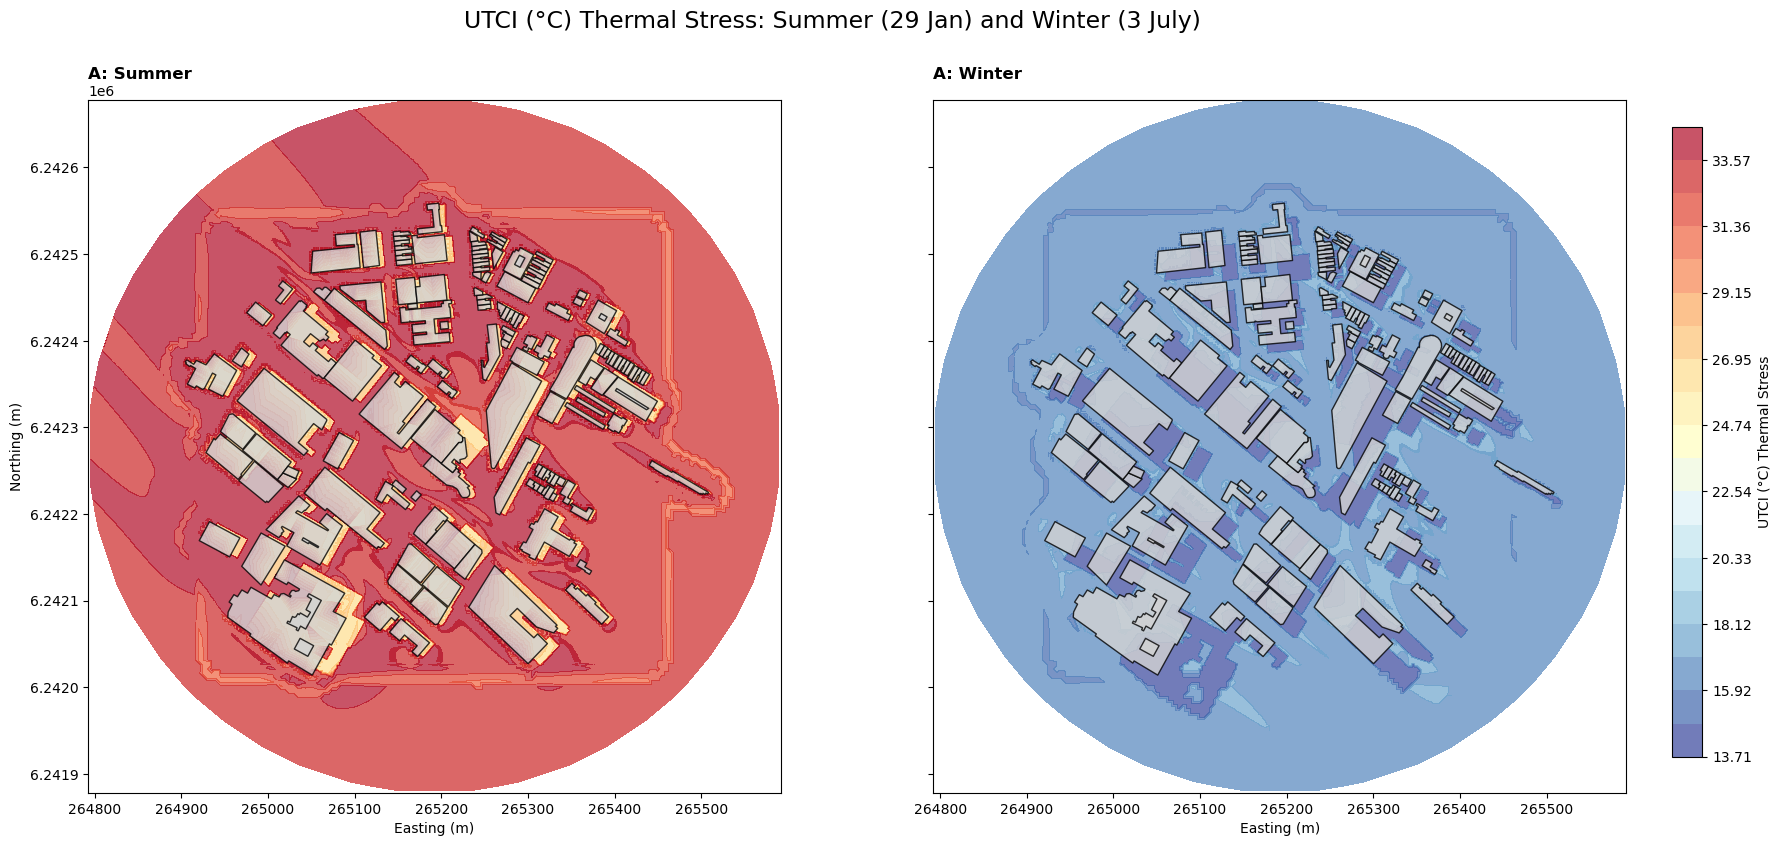

In [112]:
fig, axes = city3D.plot_utci(summer10m_df, winter10m_df, ts_copy, center_x_utm, center_y_utm, radius=radius, 
                          title_suffix="UTCI (°C) Thermal Stress: Summer (29 Jan) and Winter (3 July)")
plt.show()

<div class="alert alert-block alert-success"><b>QUESTION</b>

Why do we / is the *'gold standard'* UTCI formula calibated to use the wind at 10m but evaluates solar radiation and Thermal Comfort at ground level? 
</div>

**UTCI categories can be interpreted as follows:**

| UTCI Range (°C) | Category | Colour Map |
| :---: | :---: | :--- |
| > 38 | Very Strong Heat Stress | Dark Red | 
| 28- 30 | Strong Heat Stress | Orange/Red | 
| 26 - 32 | Moderate Heat Stress | Yellow/Orange |
| 9 - 26 | Thermal Comfort|	Blue/Yellow |

<div class="alert alert-block alert-info"><b>UTCI in the Cold Range</b> 

Because UTCI is a ***universal*** index it covers the entire spectrum from −50°C to +50°C. In winter, we simply shift to the blue end of the scale.

</div>

| UTCI Range (°C) | Category | Human Sensation |
| :---: | :---: | :--- |
| 9 - 0 | Slight Cold Stress | You need a jacket; extremities feel cool. | 
| 0- -13 | Moderate Cold Stress | Risk of hypothermia over long exposure. | 
| -13 - -27 | Strong Cold Stress | High discomfort; shivering starts. |

### c. Wind Chill Temperature Index

<div class="alert alert-block alert-warning"><b></b>
    
Generally weather services don't use the UTCI in the cold range but a [Wind Chill Temperature Index](https://en.wikipedia.org/wiki/Wind_chill) which focuses strictly on how the wind "strips" heat from the skin.  
Several standard wind chill formula exist, we execute the one adopted by [Environment Canada](https://www.canada.ca/en/services/environment/weather/severeweather/wind-chill-index.html):  

$$ WCI = 13.12 + 0.6215 * {T}_{a} −11.37 * {v}^{0.16} + 0.3965 * {T}_{a} * {v}^{0.16}  $$

</div>

In [113]:
#- calculate wind chill

# m/s to kh/m
v_kmh = winter10m_df['u_mag'] * 3.6
# raise to the power 0.16
v16 = v_kmh**0.16

winter10m_df['wind_chill'] = (
    13.12 + (0.6215 * Wta) - 
    (11.37 * v16) + (0.3965 * Wta * v16)
)
winter10m_df.head(2)

,X,Y,Z,U,V,u_mag,is_shaded,u_mag_10m,utci,wind_chill
0,264899.689301,6.242006e+06,1.877559,3.183067,-2.929980,4.326280,False,4.326280,16.59,12.792095
1,264904.689301,6.242001e+06,1.877558,3.195477,-2.899146,4.314641,False,4.314641,16.59,12.795986


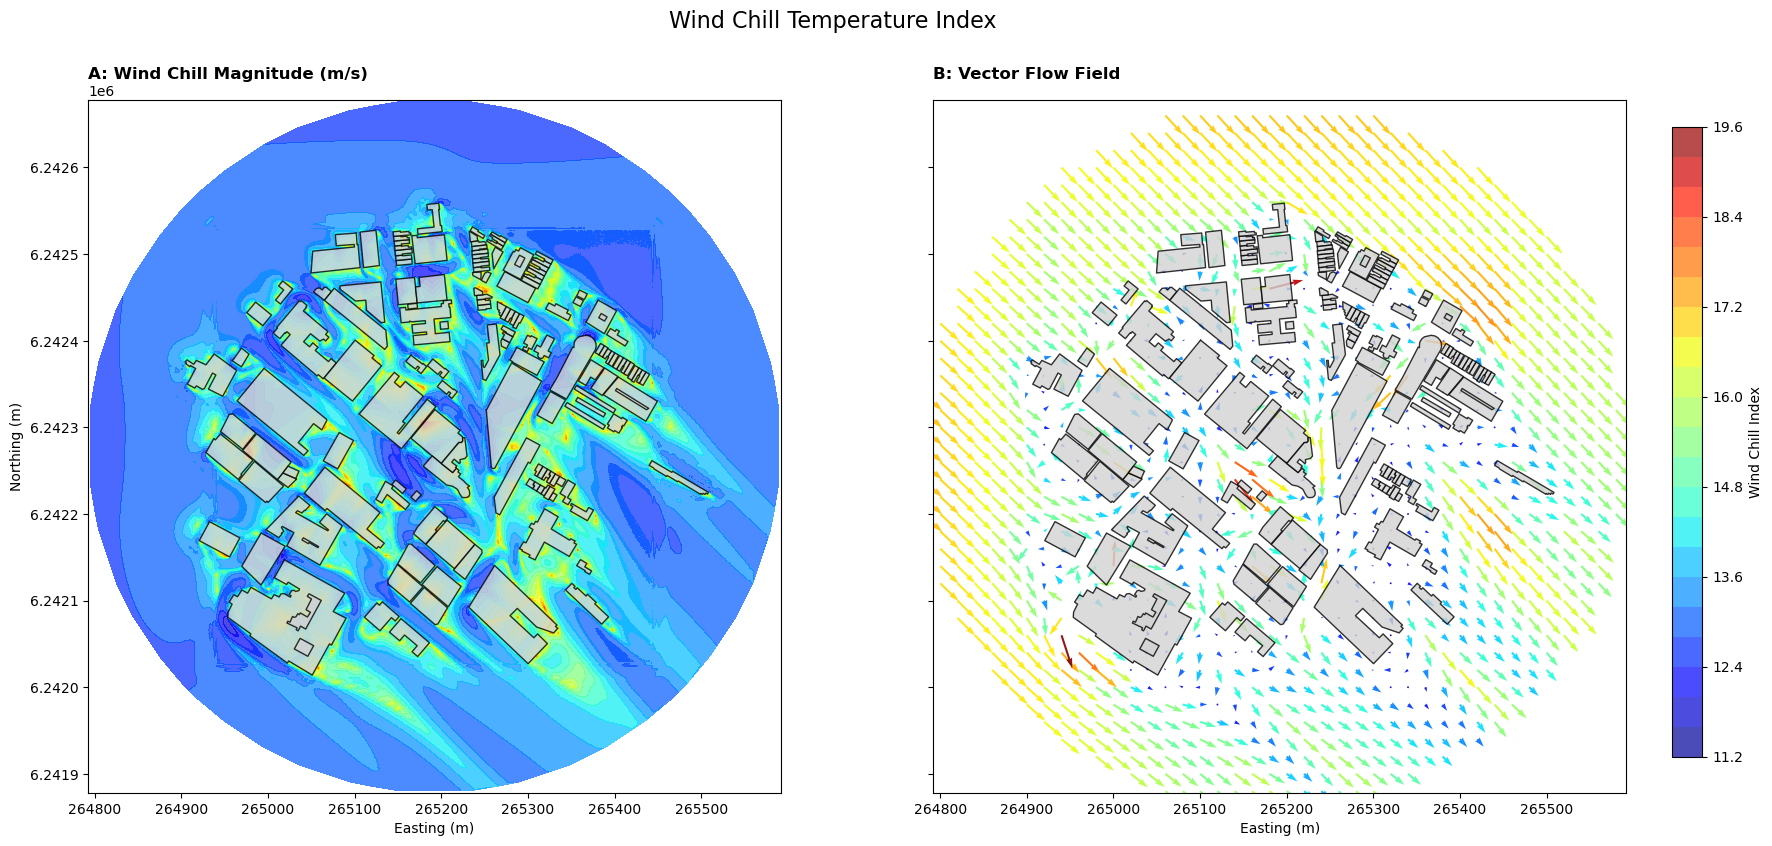

In [114]:
def plot_windChill(ped_df, buildings_df, center_x_utm, center_y_utm, radius=400):
    """
    Generates a side-by-side Velocity Magnitude and Vector Flow plot.
    center_coords: tuple (center_x_utm, center_y_utm)
    """
    #cx, cy = center_coords
    
    # 1. Setup the figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9), sharey=True)

    # --- MAP A: Magnitude (Tricontour) ---
    cntr = ax1.tricontourf(ped_df['X'], ped_df['Y'], ped_df['wind_chill'], 
                           levels=20, cmap='jet', alpha=0.7)
    
    # Use your existing plot_geometries function
    city3D.plot_geometries(buildings_df, ax=ax1, facecolor='lightgrey', edgecolor='black', alpha=0.8)
    ax1.set_title('A: Wind Chill Magnitude (m/s)', loc='left', pad=15, weight='bold')

    # --- MAP B: Flow (Quiver) ---
    # Sampling for visual clarity (skip 3 points)
    #skip = 1
    #x, y = ped_df['X'].values[::skip], ped_df['Y'].values[::skip]
    #u, v = ped_df['U'].values[::skip].astype(float), ped_df['V'].values[::skip].astype(float)
    #mags = ped_df['wind_chill'].values[::skip].astype(float)

    if len(ped_df) > 7000:
        bins = 20
    if len(ped_df) < 7000:
        bins = 10
        
    # Create bins
    ped_df['x_bin'] = (ped_df['X'] // bins) * bins
    ped_df['y_bin'] = (ped_df['Y'] // bins) * bins

    # Aggregate: Mean velocity per bin
    binned_df = ped_df.groupby(['x_bin', 'y_bin']).agg({
        'U': 'mean', 
        'V': 'mean', 
        'u_mag': 'mean'
    }).reset_index()

    # Plot binned_df instead of the raw 10M rows
    qv = ax2.quiver(binned_df['x_bin'], binned_df['y_bin'], binned_df['U'], binned_df['V'], binned_df['u_mag'], cmap='jet',
                    scale=120, alpha=0.9, width=0.003)
    #qv = ax2.quiver(x, y, u, v, mags, cmap='jet', scale=120, alpha=0.9, width=0.003)
    
    city3D.plot_geometries(buildings_df, ax=ax2, facecolor='lightgrey', edgecolor='black', alpha=0.8)
    ax2.set_title('B: Vector Flow Field', loc='left', pad=15, weight='bold')

    # --- AXIS & SPATIAL STYLING ---
    for ax in [ax1, ax2]:
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel('Easting (m)')
        # Force strict 400m AOI
        ax.set_xlim(center_x_utm - radius, center_x_utm + radius)
        ax.set_ylim(center_y_utm - radius, center_y_utm + radius)

    ax1.set_ylabel('Northing (m)')

    # --- SHARED COLORBAR (The "No Squish" Fix) ---
    fig.subplots_adjust(right=0.9) 
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7]) 
    fig.colorbar(cntr, cax=cbar_ax, label='Wind Chill Index')

    plt.suptitle(f'Wind Chill Temperature Index', fontsize=16, y=0.98)
    
    return fig, (ax1, ax2)

fig, axes = plot_windChill(winter10m_df, ts_copy, center_x_utm, center_y_utm, radius=radius)
plt.show()

<div class="alert alert-block alert-danger"><b>Disclaimer</b>

These [UTCI](https://www.utci.org) metrics and maps are a Climatological Approximation. 

It uses [CFD](https://en.wikipedia.org/wiki/Computational_fluid_dynamics)-derived wind speeds combined with local solar geometry. While it accurately identifies [wind-chill](https://en.wikipedia.org/wiki/Wind_chill) and sun-scorched areas, a Robust [**Heat-Transfer Simulation**](https://www.simscale.com/docs/analysis-types/heat-transfer/) would be required to model the 'thermal flywheel' effect of building materials *(how concrete [roads, earth, etc.] stays hot, and release heat, after the sun goes down)*

## 4. Possible Secondary and Tertiary level conversations starters
<div class="alert alert-block alert-success"><b> exchange knowledge and understanding</b></div>

| **Topic** | **Secondary Level Questions** | **Tertiary Level Questions** |
|----------|------------------------------|------------------------------|
| **Feeling the Wind in Place** | - When you walk in this area, where do you feel the wind the most?<br>- Are there places that feel calm or sheltered?<br>- How does the wind change between streets, corners, and open spaces? | - How do the simulation results compare with your own experience of wind in this area?<br>- What features of the built environment (e.g., building height, street width) might explain these differences?<br>- How could local knowledge help improve or validate the simulation? |
| **Streets, Buildings & Wind** | - How do buildings change the way wind moves through the neighborhood?<br>- Do narrow streets feel different from wide streets in terms of wind?<br>- Where do you think wind speeds up or slows down? | - Identify patterns in the simulation where wind is channelled, blocked, or redirected.<br>- How does the arrangement of buildings shape these patterns?<br>- What might this mean for how the area was designed or developed? |
| **Comfort in Everyday Spaces** | - Which places in the area feel comfortable to stand, sit, or walk in?<br>- Are there places that feel too windy or exposed?<br>- How might this affect how people use public spaces? | - Using the simulation, identify areas that may be uncomfortable for pedestrians.<br>- How could these conditions affect different groups of people (e.g., elderly, children)?<br>- What small changes could make these spaces more comfortable? |
| **Wind, Temperature & How We Feel** | - Why does a windy day sometimes feel colder than it actually is?<br>- How do sun, shade, and wind together affect how a place feels?<br>- Where in the area might feel warmer or cooler? | - How can wind speed influence perceived temperature (e.g., wind chill or thermal comfort)?<br>- How might combining wind data with weather conditions change our understanding of comfort?<br>- What kinds of places might be most affected during very hot or cold days? |
| **Comparing Places** | - Compare two different spots in the area: how does the wind feel different?<br>- What makes one place feel more comfortable than another?<br>- How might people choose where to walk or spend time based on this? | - Use the simulation to compare wind conditions across different locations.<br>- What spatial patterns emerge (e.g., exposed vs sheltered zones)?<br>- How could this influence movement, activity, or land use in the area? |
| **Improving Local Spaces** | - What changes could make windy areas more comfortable?<br>- Could trees, walls, or different building layouts help?<br>- Where would you suggest making improvements? | - Test or propose design changes based on the simulation results.<br>- How might interventions (e.g., vegetation, barriers) change wind patterns?<br>- What trade-offs might exist between airflow (cooling) and comfort? |
| **People, Place & Environment** | - How does wind affect daily life in this neighborhood?<br>- Are there times of year when wind is more noticeable?<br>- How might different people experience these conditions differently? | - How can understanding wind and comfort support better public space design?<br>- What role can local communities play in identifying environmental challenges?<br>- How could this analysis support more inclusive and livable urban spaces? |
| **Understanding the Model** | - What do you think this simulation is showing?<br>- What information do we need to model wind in a place like this?<br>- Why might the model not match reality exactly? | - What are the limitations of this type of simulation?<br>- How sensitive are results to inputs like wind direction or building data?<br>- How could field observations be used to improve the model? |